In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os 
os.chdir('/home/nazanin/github/dt-inspired-neuro-fuzzy')

In [3]:
import torch.nn.functional as F
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np
import torch.nn as nn
from model.litanfis import LitAnfis, SklearnLitAnfisWrapper
from model.unfis import UNFIS
from model.GIFT import GIFT, SklearnGIFTWrapper, MamdaniGIFT
from model.anfis import ANFIS, SklearnAnfisWrapper
from model.griffin import GRIFFIN, SklearnGRIFFINrapper
from model.giftshift import GIFTSHIFT, SklearnGIFTSHIFTWrapper, GIFTSHIFTENTROPY, SklearnGIFTSHIFTENTROPYWrapper
import torch
import torch.optim as optim
from torch.optim.lr_scheduler import OneCycleLR
from tests.evaluate import Evaluator

In [4]:
# config

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_size = 105
batch_size = 32
random_state = 199

lr = 0.005
max_lr = 0.01
epochs = 100

alpha = 1.0
min_alpha = 0.0
noise_evaluate = True

learning_params = dict(train_size=train_size,
                       batch_size=batch_size,
                       random_state=random_state,
                       lr=lr,
                       max_lr=max_lr,
                       epochs=epochs,
                       alpha=alpha,
                       min_alpha=min_alpha)

In [5]:
# datasetdec

from tests.uci_test import Cryotheraphy, Haberman, Heart, Glass, Segmentaition, Wine, Thyroid, Immunotherapy, Iris, BreastCancer, AdultIncome, BankMarketing, PimaDiabetes, CarEvaluation, Autism, Digits, DNA, MFeat, Parkinson # Synthetic2DGaussianClusters
from tests.class_test import Segmentation, Digits_UCI, Diabetes, BCW, Smoke # TODO try the following datasets Digits DNA
from torch.utils.data import DataLoader


#from tests.uci_test import Autism, CaliforniaHousing, Abalone
#from tests.class_test import Digits, Segmentation, Digits_UCI, Diabetes, BCW, DNA, Smoke, MNIST, ORL


experiment = Parkinson(session_id=random_state)
train_dataset = experiment.train_dataset(device)
test_dataset = experiment.test_dataset(device)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

learning_params['train_size'] = experiment.train_numpy()[0].shape[0]
#regression = experiment.target_type == 'regression'
regression = False

Loaded Parkinson dataset: 293 samples, 16 features
Feature names: ['coefficients_of_variations_in_duration_swing_time_left_foot', 'coefficients_of_variations_in_duration_stride_time_left_foot', 'coefficients_of_variations_in_duration_swing_time_right_foot', 'coefficients_of_variations_in_duration_stride_time_right_foot', 'coefficients_of_variations_of_the_short_swing_time', 'coefficients_of_variations_of_the_long_swing_time', 'coefficients_of_variations_of_the_gait_asymmetry', 'mean_in_percentage_swing_time_left_foot', 'mean_in_duration_swing_time_left_foot', 'mean_in_duration_stride_time_left_foot', 'mean_in_percentage_swing_time_right_foot', 'mean_in_duration_swing_time_right_foot', 'mean_in_duration_stride_time_right_foot', 'mean_of_the_short_swing_time', 'mean_of_the_long_swing_time', 'mean_of_the_gait_asymmetry']
Class distribution:
label
0     89
1    204
Name: count, dtype: int64


,Description,Value
0,Session id,199
1,Target,label
2,Target type,Binary
3,Original data shape,"(293, 17)"
4,Transformed data shape,"(293, 17)"
5,Transformed train set shape,"(234, 17)"
6,Transformed test set shape,"(59, 17)"
7,Numeric features,16
8,Preprocess,True
9,Imputation type,iterative


True

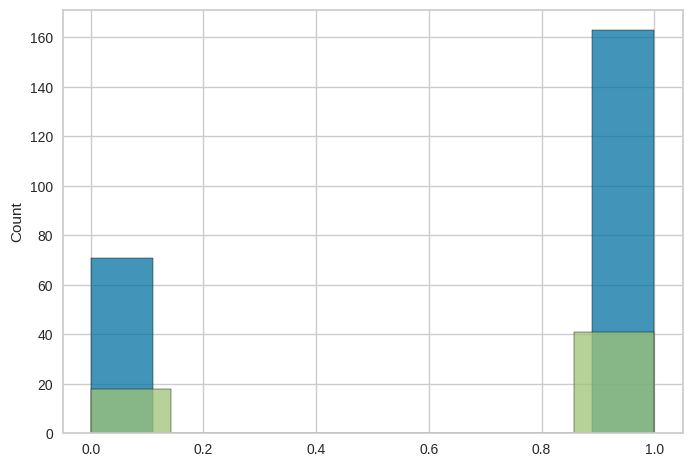

In [6]:
sns.histplot(experiment.train_numpy()[1])
sns.histplot(experiment.test_numpy()[1])

binary = len(np.unique(experiment.train_numpy()[1])) == 2
binary

In [7]:
# Configure evaluator

'''
evaluator = RobustnessEvaluator(
    experiment=experiment,
    model_params_gift={
        'in_features': experiment.train_numpy()[0].shape[1],
        'out_features': len(np.unique(experiment.train_numpy()[1])),
        'rules': 2,
        'drop_out_p': 0.3,
        'binary' : binary
    },
    model_params_litanfis={
        'in_features': experiment.train_numpy()[0].shape[1],
        'out_features': len(np.unique(experiment.train_numpy()[1])),
        'rules': 2,
        'drop_out_p': 0.3,
        'binary': binary
    },
    learning_params={
        'batch_size': 32,
        'lr': 0.005,
        'max_lr': 0.01,
        'epochs': 100,
        'alpha': 1.0,
        'min_alpha': 0.0
    },
    device=device,
    binary=binary,
    noise_levels=[0.0, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5],
    n_runs=5,
    random_state=42
)

# Run evaluation
results_df = evaluator.evaluate(verbose=True)

# Plot results
evaluator.plot_robustness_curves(save_path='robustness_curves.png')
evaluator.plot_relative_performance(save_path='relative_performance.png')

# Print detailed report
evaluator.print_detailed_report()

# Get just the best model
best_model, details = evaluator.get_best_model()
print(f"Best model: {best_model}")
print(f"Details: {details}")

'''

'\nevaluator = RobustnessEvaluator(\n    experiment=experiment,\n    model_params_gift={\n        \'in_features\': experiment.train_numpy()[0].shape[1],\n        \'out_features\': len(np.unique(experiment.train_numpy()[1])),\n        \'rules\': 2,\n        \'drop_out_p\': 0.3,\n        \'binary\' : binary\n    },\n    model_params_litanfis={\n        \'in_features\': experiment.train_numpy()[0].shape[1],\n        \'out_features\': len(np.unique(experiment.train_numpy()[1])),\n        \'rules\': 2,\n        \'drop_out_p\': 0.3,\n        \'binary\': binary\n    },\n    learning_params={\n        \'batch_size\': 32,\n        \'lr\': 0.005,\n        \'max_lr\': 0.01,\n        \'epochs\': 100,\n        \'alpha\': 1.0,\n        \'min_alpha\': 0.0\n    },\n    device=device,\n    binary=binary,\n    noise_levels=[0.0, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5],\n    n_runs=5,\n    random_state=42\n)\n\n# Run evaluation\nresults_df = evaluator.evaluate(verbose=True)\n\n# Plot results\nevaluator.plot

In [8]:
# prepare the model - modeldec

from train.early_stop import EarlyStopping

model_params = {
    'type': "giftshift", # anfis, unfis, gift, litanfis, gift-mamdani, griffin, giftshift, giftshiftentropy
    'in_features': experiment.train_numpy()[0].shape[1],
    'out_features': len(np.unique(experiment.train_numpy()[1])),
    'rules': 2,
    'drop_out_p': 0.3,
    'binary' : binary,
    #'rank': 2,
    #'eta':1  
}
zeta = 1.0
rank = 2
eta = 1 
Xi = 1

entropy_coef = 0.0005
model_type = model_params.pop('type')

if model_type == "anfis":
    model = ANFIS(**model_params, dtype=torch.float32)
    sk_model = SklearnAnfisWrapper(model, device=device)
elif model_type == "litanfis":
    model = LitAnfis(**model_params, dtype=torch.float32)
    sk_model = SklearnLitAnfisWrapper(model, device=device)
elif model_type == "unfis":
    model = UNFIS(**model_params, dtype=torch.float32)
elif model_type == "gift":
    model = GIFT(**model_params, dtype=torch.float32)
    sk_model = SklearnGIFTWrapper(model, device=device)
elif model_type == "gift-mamdani":
    model = MamdaniGIFT(**model_params, dtype=torch.float32)
    sk_model = SklearnGIFTWrapper(model, device=device)
elif model_type == "griffin":
    model = GRIFFIN(**model_params, dtype=torch.float32, zeta=1, rank=rank, eta=eta, Xi=Xi, regression=regression)
    sk_model = SklearnGRIFFINrapper(model, device=device)
elif model_type == "giftshift":
    model = GIFTSHIFT(**model_params, dtype=torch.float32)
    sk_model = SklearnGIFTSHIFTWrapper(model, device=device)
elif model_type == "giftshiftentropy":
    model = GIFTSHIFTENTROPY(**model_params, dtype=torch.float32, entropy_coef=entropy_coef)
    sk_model = SklearnGIFTSHIFTENTROPYWrapper(model, device=device)
else:
    raise ValueError("model_type should be one of anfis, unfis, gift")


optimizer = optim.Adam(model.parameters(), lr=lr)

steps_per_epoch=len(train_loader)
scheduler = OneCycleLR(optimizer, max_lr=max_lr,
                       steps_per_epoch=steps_per_epoch, epochs=epochs)

# Early stopping    
early_stopping = EarlyStopping(patience=10, delta=-0.00001)

alpha_decaying = np.power(min_alpha / alpha, (steps_per_epoch * epochs/2))

# Define criterion functions that work for both model types
cos = nn.L1Loss()

if binary:
    cross = nn.BCEWithLogitsLoss()
    
    def criterion(batch_X, batch_y, outputs, reconstructed, entropy_penalty=None, alpha=1.0, entropy_coef=0.0):
        main_loss = cross(outputs.squeeze(), batch_y.squeeze())
        reconstruction_loss = cos(reconstructed, batch_X) * alpha
        if entropy_penalty is not None and entropy_coef > 0:
            entropy_loss = entropy_penalty * entropy_coef
            return main_loss + reconstruction_loss + entropy_loss
        return main_loss + reconstruction_loss

else:
    cross = nn.CrossEntropyLoss()

    def criterion(batch_X, batch_y, outputs, reconstructed, entropy_penalty=None, alpha=1.0, entropy_coef=0.0):
        main_loss = cross(outputs, batch_y.long())
        reconstruction_loss = cos(reconstructed, batch_X) * alpha
        if entropy_penalty is not None and entropy_coef > 0:
            entropy_loss = entropy_penalty * entropy_coef
            return main_loss + reconstruction_loss + entropy_loss
        return main_loss + reconstruction_loss

In [9]:
# train

import random
import matplotlib.pyplot as plt

def set_random_state(seed: int | None = None):
    if seed is None:
        # Generate a random seed from system entropy
        seed = np.random.randint(0, 2**32 - 1)

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    return seed

set_random_state()

history = []

# Initialize lists to store entropy values for plotting
train_entropy_values = []
val_entropy_values = []
epochs_list = []

# Determine if model has entropy regularization
has_entropy_reg = hasattr(model, 'entropy_coef')
if has_entropy_reg:
    print(f"Using entropy regularization with coefficient: {model.entropy_coef}")

for epoch in range(epochs):
    
    model.train()
    train_loss = 0
    train_reconstruction_loss = 0
    train_entropy_sum = 0 if has_entropy_reg else None

    if model_type == 'gift' or model_type == "litanfis":
        stats = model.get_interpretable_params()
        stats["epoch"] = epoch
        history.append(stats)

        if epoch % 10 == 0:
            print(f"Epoch {epoch}: {stats}")

    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        
        # Forward pass - handles both GIFTSHIFT and GIFTSHIFTENTROPY
        outputs = model(batch_X)
        
        # Unpack based on return type
        if len(outputs) == 3:
            outputs, reconstructed, entropy_penalty = outputs
        else:
            outputs, reconstructed = outputs
            entropy_penalty = None
        
        # Calculate loss based on model type
        if has_entropy_reg and entropy_penalty is not None:
            # GIFTSHIFTENTROPY with entropy regularization
            loss = criterion(
                batch_X, batch_y, outputs, reconstructed, 
                entropy_penalty, alpha, model.entropy_coef
            )
            train_entropy_sum += entropy_penalty.item() * batch_X.size(0)
        else:
            # Original GIFTSHIFT without entropy regularization
            try:
                loss = criterion(batch_X, batch_y, outputs, reconstructed, None, alpha, 0.0)
            except TypeError:
                loss = criterion(batch_X, batch_y, outputs, reconstructed, alpha)
        
        total_loss = loss
        total_loss.backward()
        optimizer.step()
        
        # Step the scheduler
        try:
            scheduler.step()
        except ValueError as e:
            if "Tried to step" in str(e) and "total steps" in str(e):
                pass
            else:
                raise
        
        # Accumulate losses
        train_loss += loss.item() * batch_X.size(0)
        train_reconstruction_loss += torch.nn.functional.l1_loss(reconstructed, batch_X).item() * batch_X.size(0)
    
    alpha *= alpha_decaying
    train_loss /= len(train_loader.dataset)
    train_reconstruction_loss /= len(train_loader.dataset)
    
    # Calculate average training entropy
    if has_entropy_reg and train_entropy_sum is not None:
        train_entropy_avg = train_entropy_sum / len(train_loader.dataset)
        train_entropy_values.append(train_entropy_avg)
    else:
        train_entropy_avg = 0.0
    
    # Validation
    model.eval()
    val_loss = 0
    val_entropy_sum = 0
    
    with torch.no_grad():
        for data, target in test_loader:
            output_tuple = model(data)
            
            # Get predictions and entropy
            if len(output_tuple) == 3:
                output, _, entropy_penalty = output_tuple
                if has_entropy_reg:
                    val_entropy_sum += entropy_penalty.item() * data.size(0)
            else:
                output, _ = output_tuple
            
            if binary:
                loss = cross(output.squeeze(), target.squeeze())
            else:
                loss = cross(output, target.long())
            
            val_loss += loss.item() * data.size(0)
    
    val_loss /= len(test_loader.dataset)
    
    # Calculate average validation entropy
    if has_entropy_reg:
        val_entropy_avg = val_entropy_sum / len(test_loader.dataset)
        val_entropy_values.append(val_entropy_avg)
    else:
        val_entropy_avg = 0.0
    
    # Store epoch number
    epochs_list.append(epoch + 1)
    
    # Print progress with entropy values
    if has_entropy_reg:
        print(f'Epoch {epoch+1:3d} | Train Loss: {train_loss:.4f} | Recon Loss: {train_reconstruction_loss:.4f} | Train Entropy: {train_entropy_avg:.6f} | Val Entropy: {val_entropy_avg:.6f} | Val Loss: {val_loss:.4f}')
    else:
        print(f'Epoch {epoch+1:3d} | Train Loss: {train_loss:.4f} | Recon Loss: {train_reconstruction_loss:.4f} | Val Loss: {val_loss:.4f}')
    
    early_stopping(val_loss, model)
    if early_stopping.early_stop:
        print("Early stopping")
        break
    
early_stopping.load_best_model(model)

# ============================================================================
# PLOT ENTROPY CURVES
# ============================================================================

if has_entropy_reg and train_entropy_values:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Entropy over epochs
    ax1 = axes[0]
    ax1.plot(epochs_list[:len(train_entropy_values)], train_entropy_values, 'b-', linewidth=2, label='Train Entropy', marker='o', markersize=4)
    if val_entropy_values:
        ax1.plot(epochs_list[:len(val_entropy_values)], val_entropy_values, 'r-', linewidth=2, label='Val Entropy', marker='s', markersize=4)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Entropy (per sample average)', fontsize=12)
    ax1.set_title('Entropy Minimization Progress', fontsize=14)
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)
    
    # Add annotation showing if entropy decreased
    if train_entropy_values[0] > train_entropy_values[-1]:
        ax1.text(0.02, 0.95, '✅ Entropy Decreasing (Good!)', transform=ax1.transAxes, 
                fontsize=11, color='green', bbox=dict(boxstyle="round,pad=0.3", facecolor='lightgreen'))
    else:
        ax1.text(0.02, 0.95, '⚠️ Entropy NOT Decreasing', transform=ax1.transAxes, 
                fontsize=11, color='red', bbox=dict(boxstyle="round,pad=0.3", facecolor='lightcoral'))
    
    # Plot 2: Entropy reduction over time
    ax2 = axes[1]
    entropy_reduction = [train_entropy_values[0] - e for e in train_entropy_values]
    ax2.fill_between(epochs_list[:len(entropy_reduction)], 0, entropy_reduction, alpha=0.5, color='green')
    ax2.plot(epochs_list[:len(entropy_reduction)], entropy_reduction, 'g-', linewidth=2, marker='o', markersize=4)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Entropy Reduction', fontsize=12)
    ax2.set_title(f'Total Entropy Reduction: {entropy_reduction[-1]:.4f}', fontsize=14)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('entropy_curves.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print summary
    print("\n" + "="*60)
    print("ENTROPY SUMMARY")
    print("="*60)
    print(f"Initial Train Entropy: {train_entropy_values[0]:.6f}")
    print(f"Final Train Entropy:   {train_entropy_values[-1]:.6f}")
    print(f"Entropy Reduction:     {train_entropy_values[0] - train_entropy_values[-1]:.6f}")
    print(f"Reduction %:           {(1 - train_entropy_values[-1]/train_entropy_values[0])*100:.2f}%")
    
    if val_entropy_values:
        print(f"\nInitial Val Entropy:   {val_entropy_values[0]:.6f}")
        print(f"Final Val Entropy:     {val_entropy_values[-1]:.6f}")
        print(f"Val Reduction:         {val_entropy_values[0] - val_entropy_values[-1]:.6f}")
    
    # Warning for collapse
    if train_entropy_values[-1] < 0.01:
        print("\n⚠️ WARNING: Very low entropy (< 0.01)! Possible rule collapse. Reduce entropy_coef.")
    elif train_entropy_values[-1] > 1.0:
        print("\n⚠️ WARNING: High entropy (> 1.0)! Rules not specializing. Increase entropy_coef.")
    else:
        print(f"\n✅ Healthy entropy level: {train_entropy_values[-1]:.6f}")
    
    print(f"\n✅ Plot saved to 'entropy_curves.png'")
    print("="*60)

print("\n✅ Training complete!")

Epoch   1 | Train Loss: 1.5906 | Recon Loss: 0.8976 | Val Loss: 0.6898
Epoch   2 | Train Loss: 0.6873 | Recon Loss: 0.8986 | Val Loss: 0.6846
Epoch   3 | Train Loss: 0.6811 | Recon Loss: 0.8941 | Val Loss: 0.6783
Epoch   4 | Train Loss: 0.6741 | Recon Loss: 0.8925 | Val Loss: 0.6703
Epoch   5 | Train Loss: 0.6646 | Recon Loss: 0.8933 | Val Loss: 0.6604
Epoch   6 | Train Loss: 0.6501 | Recon Loss: 0.8932 | Val Loss: 0.6478
Epoch   7 | Train Loss: 0.6388 | Recon Loss: 0.8873 | Val Loss: 0.6326
Epoch   8 | Train Loss: 0.6186 | Recon Loss: 0.8919 | Val Loss: 0.6153
Epoch   9 | Train Loss: 0.6035 | Recon Loss: 0.8868 | Val Loss: 0.5949
Epoch  10 | Train Loss: 0.5874 | Recon Loss: 0.8839 | Val Loss: 0.5732
Epoch  11 | Train Loss: 0.5683 | Recon Loss: 0.8885 | Val Loss: 0.5490
Epoch  12 | Train Loss: 0.5440 | Recon Loss: 0.8828 | Val Loss: 0.5247
Epoch  13 | Train Loss: 0.5414 | Recon Loss: 0.8773 | Val Loss: 0.5020
Epoch  14 | Train Loss: 0.5046 | Recon Loss: 0.8824 | Val Loss: 0.4785
Epoch 

In [10]:
# Evaluate Model: Classification Report, AUC, and Hyperparameters


from sklearn.metrics import classification_report, roc_auc_score
import pprint
import numpy as np

# Get raw labels (might be 1D or one‑hot)
y_train_raw = experiment.train_numpy()[1]
y_test_raw  = experiment.test_numpy()[1]

# Convert to 1D if necessary
if y_train_raw.ndim == 2:
    y_train = np.argmax(y_train_raw, axis=1)
    y_test  = np.argmax(y_test_raw, axis=1)
else:
    y_train = y_train_raw
    y_test  = y_test_raw

# Get predicted probabilities
y_train_proba = sk_model.predict_proba(experiment.train_numpy()[0])
y_test_proba  = sk_model.predict_proba(experiment.test_numpy()[0])

# For binary classification, roc_auc_score expects probability of the positive class
if binary:
    # If probabilities have 2 columns, take the second column (positive class)
    if y_train_proba.shape[1] == 2:
        y_train_proba_bin = y_train_proba[:, 1]
        y_test_proba_bin  = y_test_proba[:, 1]
    else:
        y_train_proba_bin = y_train_proba[:, 0]
        y_test_proba_bin  = y_test_proba[:, 0]
    train_auc = roc_auc_score(y_train, y_train_proba_bin)
    test_auc  = roc_auc_score(y_test,  y_test_proba_bin)
else:
    train_auc = roc_auc_score(y_train, y_train_proba, multi_class='ovr')
    test_auc  = roc_auc_score(y_test,  y_test_proba, multi_class='ovr')

# Build result string
result = ""
result += f'Experiment Result {experiment.__class__.__name__}\n'
result += '------ train ------\n'
result += classification_report(y_train, sk_model.predict(experiment.train_numpy()[0]), digits=4)
result += f'AUC\t{train_auc}\n'
result += '------ test ------\n'
result += classification_report(y_test, sk_model.predict(experiment.test_numpy()[0]), digits=4)
result += f'AUC\t{test_auc}\n'

result += f'{pprint.pformat(model_params)}\n'
result += pprint.pformat(learning_params)

print(result)

Experiment Result Parkinson
------ train ------
              precision    recall  f1-score   support

           0     1.0000    0.8732    0.9323        71
           1     0.9477    1.0000    0.9731       163

    accuracy                         0.9615       234
   macro avg     0.9738    0.9366    0.9527       234
weighted avg     0.9636    0.9615    0.9608       234
AUC	0.9981854316080533
------ test ------
              precision    recall  f1-score   support

           0     1.0000    0.8333    0.9091        18
           1     0.9318    1.0000    0.9647        41

    accuracy                         0.9492        59
   macro avg     0.9659    0.9167    0.9369        59
weighted avg     0.9526    0.9492    0.9477        59
AUC	1.0
{'binary': True,
 'drop_out_p': 0.3,
 'in_features': 16,
 'out_features': 2,
 'rules': 2}
{'alpha': 1.0,
 'batch_size': 32,
 'epochs': 100,
 'lr': 0.005,
 'max_lr': 0.01,
 'min_alpha': 0.0,
 'random_state': 199,
 'train_size': 234}



VISUALIZING COMPLETE FUZZY LAW STRUCTURE
Antecedent (IF) + Consequent (THEN) Parts

📊 Plotting complete fuzzy laws (antecedent + consequent)...
✅ Complete fuzzy laws saved to ./law_visualizations/complete_fuzzy_laws.png

📊 Plotting law activation patterns...
✅ Law activation map saved to ./law_visualizations/law_activation_map.png

EXTRACTED FUZZY LAWS (IF-THEN RULES)

📜 LAW #1

🔍 IF (Antecedent):
------------------------------------------------------------
    Pix_0_0 is around -0.194
    Pix_0_1 is less than -0.037
    Pix_0_2 is around 0.320
    Pix_0_3 is around 0.353
    Pix_0_4 is around 0.673
    Pix_0_5 is around 0.323
    Pix_0_6 is around 0.798
    Pix_0_7 is around -0.148

🎯 THEN (Consequent):
------------------------------------------------------------
    y = 0.1299
        + 0.1391 · (Pix_0_0 - -0.194)
        + 0.3861 · (Pix_0_1 - -0.037)
        + 0.2097 · (Pix_0_2 - 0.320)
        + 0.2031 · (Pix_0_3 - 0.353)
        + 0.0997 · (Pix_0_4 - 0.673)
        - 0.0266 · (Pi

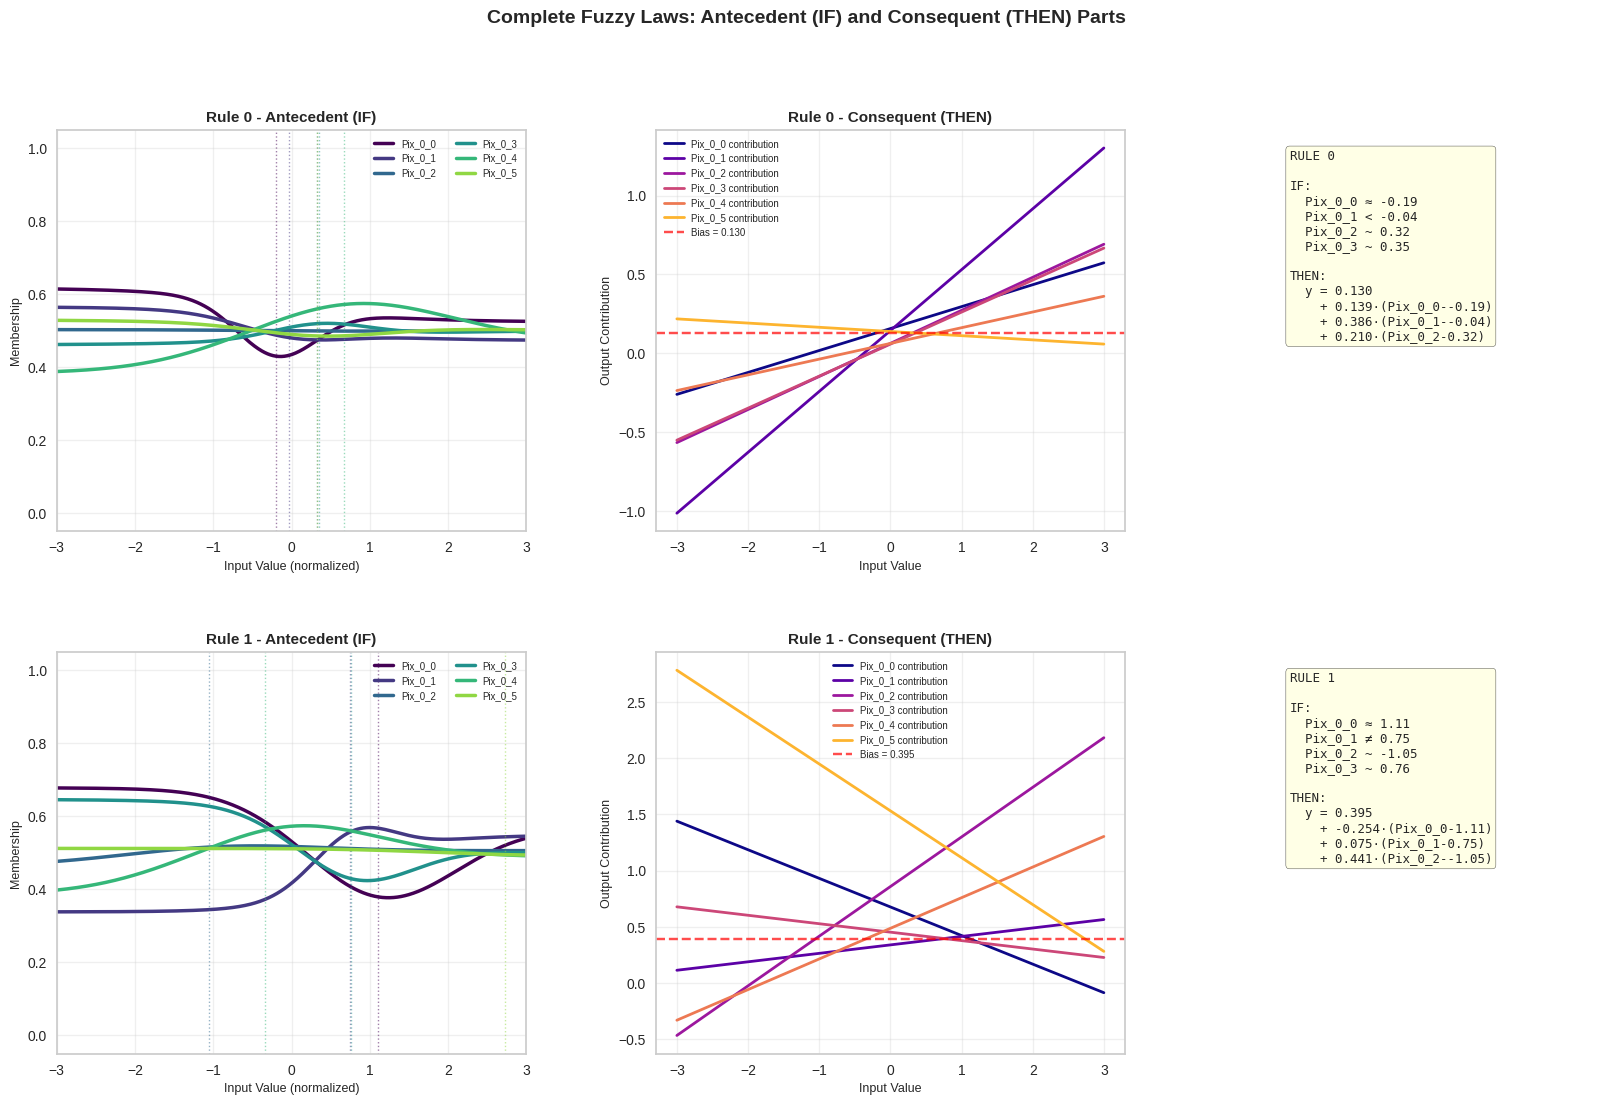

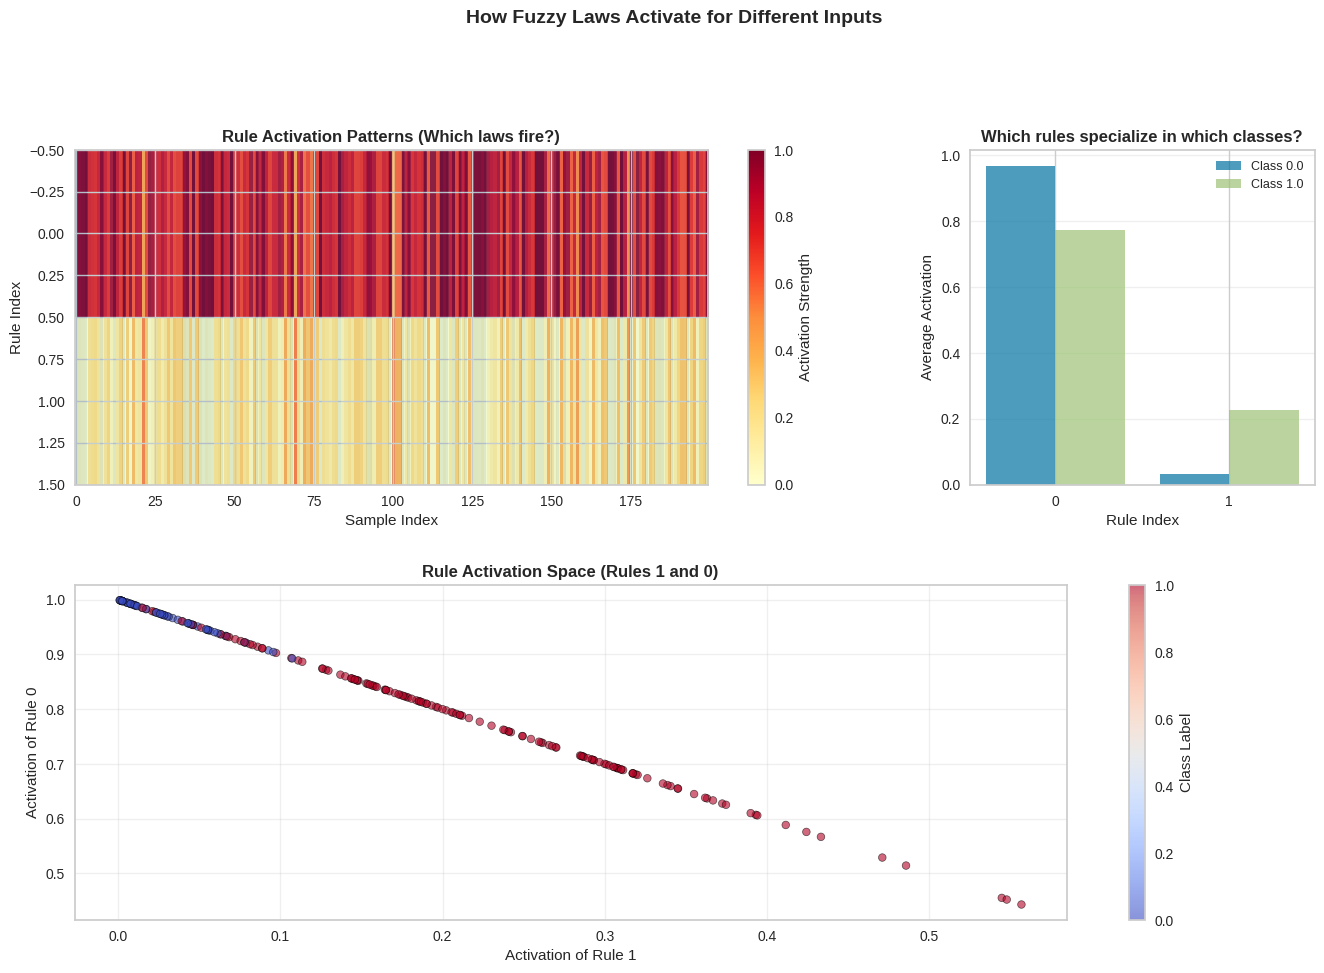

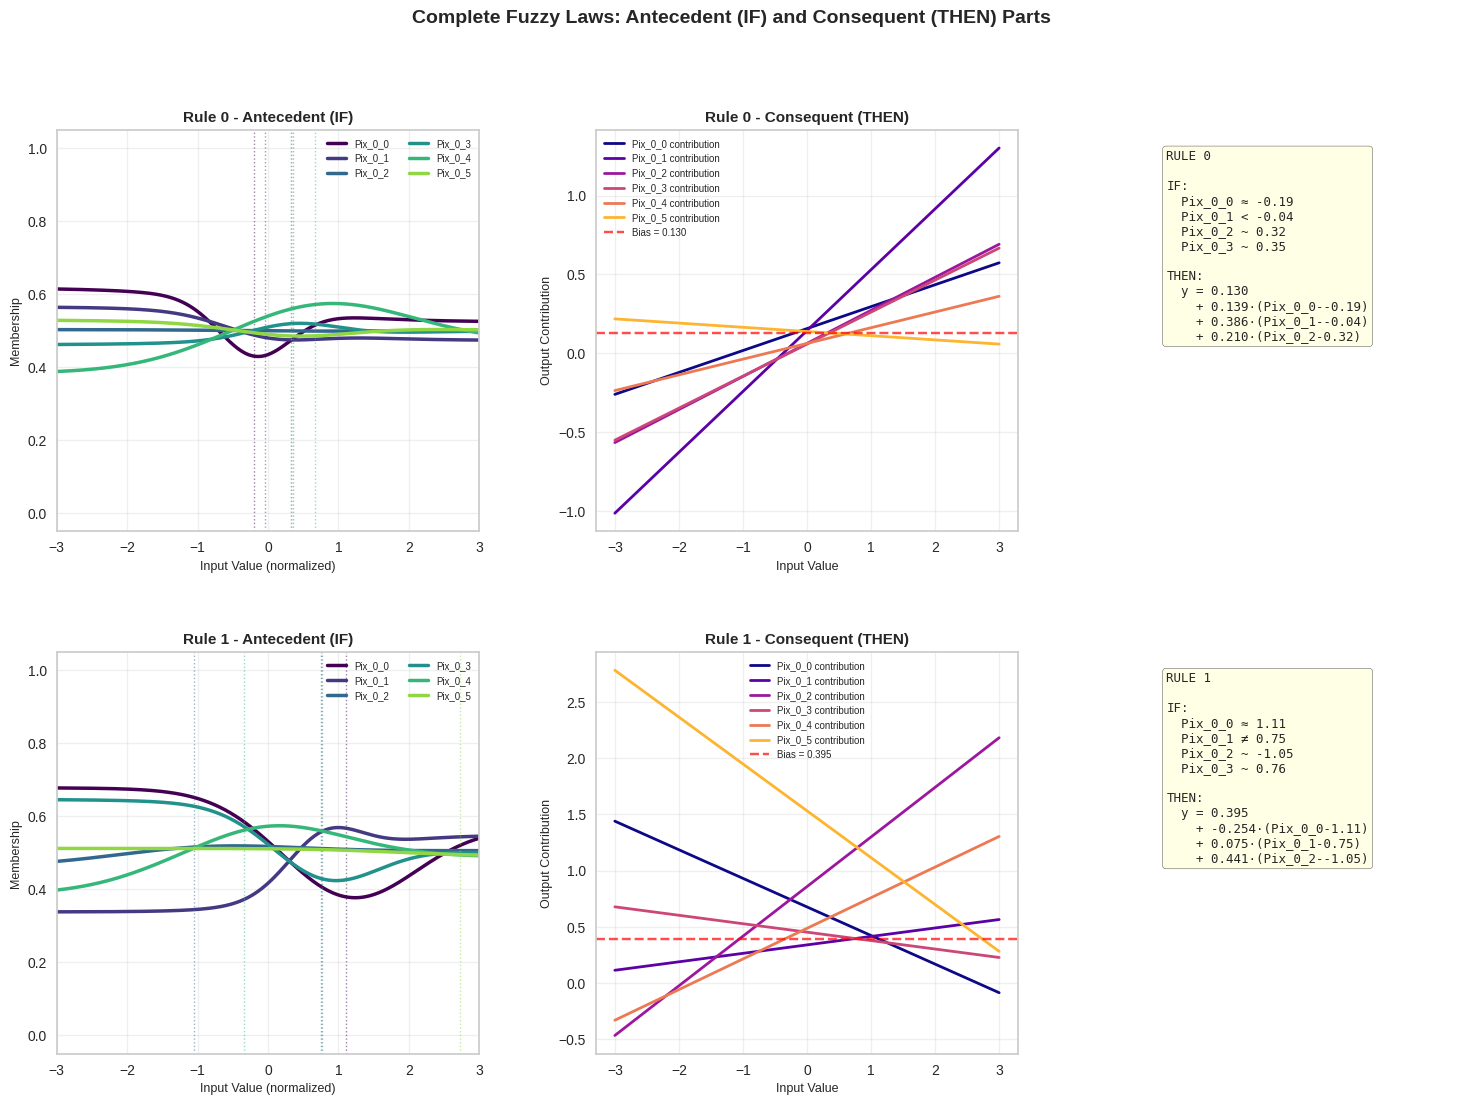

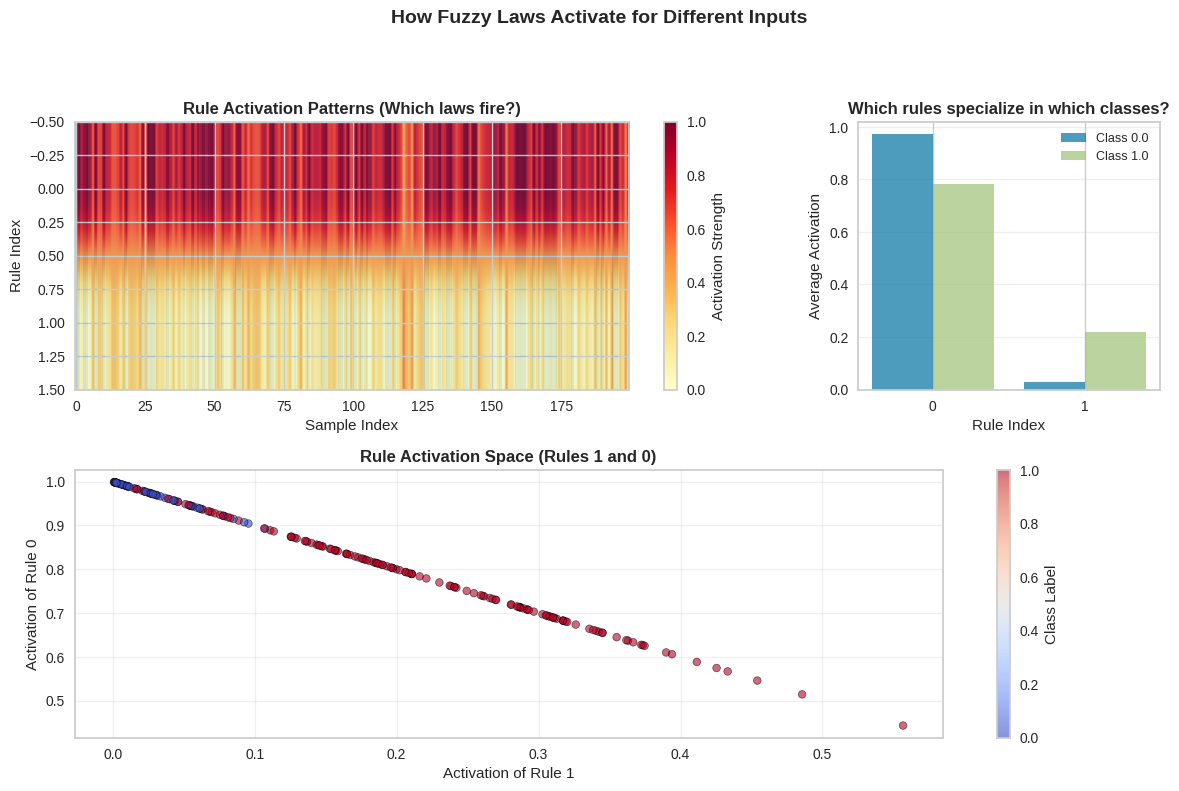

In [11]:
# plot the complete fuzzy laws (both antecedent and consequent)
from model.law_visualization import (
    plot_fuzzy_laws_complete,
    plot_law_activation_map,
    visualize_complete_law_structure,
    print_fuzzy_rules_structured
)

# ============================================================================
# VISUALIZE COMPLETE FUZZY LAWS (ANTECEDENT + CONSEQUENT)
# ============================================================================

if model_type in ["gift", "gift-mamdani", "giftshift", "giftshiftentropy"]:
    X_train_np, y_train_np = experiment.train_numpy()
    
    # Create feature names for digits (8x8 = 64 pixels)
    feature_names_digits = [f'Pix_{r}_{c}' for r in range(8) for c in range(8)]
    
    # Create class names for digits 0-9
    class_names_digits = [str(i) for i in range(10)]
    
    # Option 1: Complete visualization with both antecedent and consequent
    visualize_complete_law_structure(
        model=model,
        dataloader=train_loader,  # For activation analysis
        feature_names=feature_names_digits[:12],  # Show first 12 pixels for readability
        class_names=class_names_digits,
        rule_indices=[0, 1, 2, 3],  # Show first 4 rules (adjust as needed)
        save_dir='./law_visualizations'  # Saves figures to disk
    )
    
    # Option 2: Just plot the complete laws (antecedent + consequent)
    plot_fuzzy_laws_complete(
        model=model,
        feature_names=feature_names_digits[:8],
        class_names=class_names_digits,
        rule_indices=[0, 1, 2],  # Plot rules 0,1,2
        figsize=(18, 12),
        save_path='./complete_fuzzy_laws.png'
    )
    
    # Option 3: Print structured human-readable rules
    print_fuzzy_rules_structured(
        model=model,
        feature_names=feature_names_digits[:10],
        class_names=class_names_digits
    )
    
    # Option 4: Plot law activation map (shows which laws fire for which digits)
    plot_law_activation_map(
        model=model,
        dataloader=train_loader,
        feature_names=feature_names_digits[:8],
        class_names=class_names_digits,
        num_samples=200,
        figsize=(14, 8),
        save_path='./law_activation_patterns.png'
    )

elif model_type == 'litanfis':
    X_train_np, y_train_np = experiment.train_numpy()
    plot_litanfis_mfs(model, feature_names=None)

In [12]:
'''from model.visual import visualize_full_fuzzy_system

visualize_full_fuzzy_system(
    model,
    image_shape=(8, 8)
)'''

'from model.visual import visualize_full_fuzzy_system\n\nvisualize_full_fuzzy_system(\n    model,\n    image_shape=(8, 8)\n)'

In [13]:
with open(f'results/{model_type}_{experiment.__class__.__name__}_{model_params["rules"]}.txt', mode='w') as f:
    f.write(result)

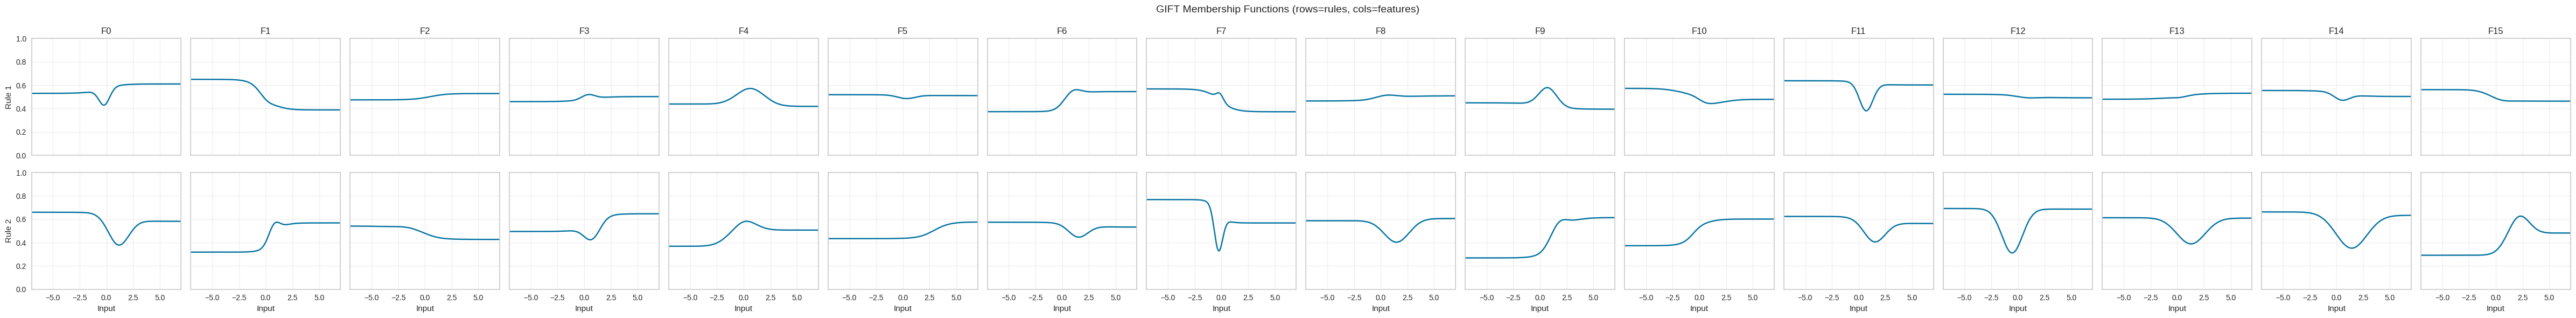

In [14]:
# plot the membership functions
from model.mf_plot import plot_litanfis_mfs, plot_gift_mfs, plot_gift_param_progress
if model_type == "gift" or model_type == "gift-mamdani" or model_type == "giftshift" or model_type == "giftshiftentropy":
    X_train_np, y_train_np = experiment.train_numpy() 
    plot_gift_mfs(model, feature_names=None)


if model_type == 'litanfis':
    X_train_np, y_train_np = experiment.train_numpy()
    plot_litanfis_mfs(model, feature_names=None)


In [15]:
# ROC Curve (Binary or One‑vs‑Rest) with Zoom-in on High Performance
'''import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn.preprocessing import label_binarize

X_test, y_test = experiment.test_numpy()
y_score = sk_model.predict_proba(X_test)

classes = np.unique(y_test)
n_classes = len(classes)

plt.figure(figsize=(8, 8), dpi=200)

# Binary classification
if n_classes == 2:
    # Determine which column(s) to use
    if y_score.shape[1] == 2:
        # Standard case: two columns, second is probability of positive class
        y_score_bin = y_score[:, 1]
    elif y_score.shape[1] == 1:
        # Single column: assume it's probability of the positive class
        y_score_bin = y_score[:, 0]
    else:
        raise ValueError(f"Unexpected y_score shape: {y_score.shape}")

    fpr, tpr, _ = roc_curve(y_test, y_score_bin)
    roc_auc = auc(fpr, tpr)

    RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,
                    estimator_name='Binary classifier').plot()

# Multiclass classification
else:
    # Binarize labels (One-vs-Rest)
    y_test_bin = label_binarize(y_test, classes=classes)

    for i, cls in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, label=f"Class {cls} (AUC = {roc_auc:.3f})")

    plt.legend(loc="lower right")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve (One-vs-Rest)")

# Zoom
plt.xlim([0.0, 0.025])
plt.ylim([0.99, 1.0])
plt.grid(True)

plt.show()'''


'import numpy as np\nimport matplotlib.pyplot as plt\nfrom sklearn.metrics import roc_curve, auc, RocCurveDisplay\nfrom sklearn.preprocessing import label_binarize\n\nX_test, y_test = experiment.test_numpy()\ny_score = sk_model.predict_proba(X_test)\n\nclasses = np.unique(y_test)\nn_classes = len(classes)\n\nplt.figure(figsize=(8, 8), dpi=200)\n\n# Binary classification\nif n_classes == 2:\n    # Determine which column(s) to use\n    if y_score.shape[1] == 2:\n        # Standard case: two columns, second is probability of positive class\n        y_score_bin = y_score[:, 1]\n    elif y_score.shape[1] == 1:\n        # Single column: assume it\'s probability of the positive class\n        y_score_bin = y_score[:, 0]\n    else:\n        raise ValueError(f"Unexpected y_score shape: {y_score.shape}")\n\n    fpr, tpr, _ = roc_curve(y_test, y_score_bin)\n    roc_auc = auc(fpr, tpr)\n\n    RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,\n                    estimator_name=\'Binary classifier

In [16]:
# Import necessary modules
import torch
import numpy as np
from tests.evaluate import Evaluator  # or wherever your Evaluator is located

# Configure device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# Define model configurations
model_configs = {
    'GIFT': {
        'model_class': GIFT,
        'wrapper_class': SklearnGIFTWrapper,
        'params': {
            'rules': 2,
            'drop_out_p': 0.3,
        }
    },
    'GIFTSHIFT': {
        'model_class': GIFTSHIFT,
        'wrapper_class': SklearnGIFTSHIFTWrapper,
        'params': {
            'rules': 2,
            'drop_out_p': 0.3,
        }
    }

} 

'''

'Litanfis': {
        'model_class': LitAnfis,
        'wrapper_class': SklearnLitAnfisWrapper,
        'params': {
            'rules': 2,
            'drop_out_p': 0.3,
        }
    }, 

'GIFTSHIFTENTROPY': {
        'model_class': GIFTSHIFTENTROPY,
        'wrapper_class': SklearnGIFTSHIFTENTROPYWrapper,
        'params': {
            'rules': 2,
            'drop_out_p': 0.3,
            'entropy_coef': 0.0005
        }
    }


'GIFTSHIFT': {
        'model_class': GIFTSHIFT,
        'wrapper_class': SklearnGIFTSHIFTWrapper,
        'params': {
            'rules': 2,
            'drop_out_p': 0.3,
        }
    }

'''


# Define learning parameters
learning_params = {
    'batch_size': 32,
    'lr': 0.005,
    'max_lr': 0.01,
    'epochs': 100,
    'alpha': 1.0,
    'min_alpha': 0.0
}

# Create evaluator instance
evaluator = Evaluator(
    experiment=experiment,
    model_configs=model_configs,
    learning_params=learning_params,
    device=device,
    binary=binary,
    noise_levels=[0.0, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5],
    n_runs=5,
    random_state=42,  # Set to None for random results each run
    use_noise=False,   # Set to False for clean data only
    noise_type="gaussian"  # or "salt_pepper"
)

# Run evaluation
results_df = evaluator.evaluate(verbose=True)

# Print detailed report
evaluator.print_detailed_report()

# Plot results (only if noise is enabled)
if evaluator.use_noise:
    evaluator.plot_robustness_curves(save_path="robustness_curves.png")
    evaluator.plot_relative_performance(save_path="relative_performance.png")


🔇 NOISE IS DISABLED - Clean data evaluation only


Noise levels:   0%|          | 0/1 [00:00<?, ?it/s]


Testing: CLEAN DATA (σ = 0)

Training GIFT...
  Run 1/5... Acc=0.9492
  Run 2/5... Acc=0.9492
  Run 3/5... Acc=0.9831
  Run 4/5... Acc=0.9661
  Run 5/5... Acc=0.9492

Training GIFTSHIFT...
  Run 1/5... Acc=0.9492
  Run 2/5... Acc=0.9322
  Run 3/5... Acc=0.9492
  Run 4/5... Acc=0.9661
  Run 5/5... 

Noise levels: 100%|██████████| 1/1 [00:50<00:00, 50.77s/it]

Acc=0.9492

MODEL EVALUATION REPORT
Dataset: Parkinson
Noise Enabled: False
Number of runs per configuration: 5

📊 PERFORMANCE SUMMARY:
--------------------------------------------------------------------------------
Model           Noise σ    Test Acc ± Std       Test AUC ± Std      
--------------------------------------------------------------------------------
GIFT            Clean      0.9593 ± 0.0136    0.9997 ± 0.0005
GIFTSHIFT       Clean      0.9492 ± 0.0107    0.9997 ± 0.0005

🏆 VERDICT:
--------------------------------------------------------------------------------
✅ BEST MODEL: GIFTSHIFT
📝 Reason: GIFTSHIFT outperforms on clean data: +1.02% accuracy, +0.00% AUC

Detailed criteria comparison:
  • test_accuracy: GIFT
  • test_auc: GIFTSHIFT
  • more_stable: GIFTSHIFT
